## LOGISTIC REGRESSION - CREDIT CARD FRAUD DETECTION

### EDA - HOMEWORK

In [157]:
%pip install imblearn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [158]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,ConfusionMatrixDisplay,f1_score,roc_auc_score,classification_report
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as py
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE


In [179]:
CreditCarddf = pd.read_csv("D:\\Veena\\Certificate Program in AI and ML\\Certificate-Program-in-AIML-IIT-Patna\\MODULE 2 - CLASSICAL ML\\Dataset\\creditcard.csv")
CreditCarddf.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [160]:
totalTrans = len(CreditCarddf)
fruadTrans = (CreditCarddf['Class'] == 1).sum()
legitTrans = (CreditCarddf['Class'] == 0).sum()

print(f"Out of Total transaction of {totalTrans}, {fruadTrans} are fraud transactions and {legitTrans} are legit transactions")

print(f"{((fruadTrans)/totalTrans): .2%} are fraud transactions and {((legitTrans)/totalTrans): .2%} are legit transactions")


Out of Total transaction of 284807, 492 are fraud transactions and 284315 are legit transactions
 0.17% are fraud transactions and  99.83% are legit transactions


In [161]:
print(f"Total null values in the dataset: {CreditCarddf.isnull().sum().sum()}")

print(f"Details of Amount field: {CreditCarddf['Amount'].describe()}")

Total null values in the dataset: 0
Details of Amount field: count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


In [162]:
#The use of axis=1, is to specify thst Class is a column. By default axis=0=, meaning rows. So, if we don't give anything, then system searches fro row 'Age'.
X = CreditCarddf.drop('Class', axis=1)
Y = CreditCarddf['Class']

#int(f"Shape of X: {X.shape}")
#print(f"Shape of Y: {Y.shape}")

xTrain,xTest,yTrain,yTest = train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

#print(f"Shape of xTrain: {xTrain.shape}")
#print(f"Shape of xTest: {xTest.shape}")
#print(f"Shape of yTrain: {yTrain.shape}")
#print(f"Shape of yTest: {yTest.shape}")

dataList = [
    ("Training Data",yTrain),
    ("Testing Data",yTest)
]
print("Split of fraud and legit transaction :")

for name,data in dataList:
    legit = (data == 0).sum()
    fraud = (data == 1).sum()
    print(f"{name}: \n Legit: {legit/len(data):2%} precentage, count: {legit}")
    print(f"Fraud: {fraud/len(data):2%} precentage, count: {fraud}")




Split of fraud and legit transaction :
Training Data: 
 Legit: 99.827075% precentage, count: 227451
Fraud: 0.172925% precentage, count: 394
Testing Data: 
 Legit: 99.827955% precentage, count: 56864
Fraud: 0.172045% precentage, count: 98


### The data is already scaled, so need to scale again(given in kaggle website)
This is what we will thing if we see the data, but we have to analyse if teh data is really scaled.

In [163]:
CreditCarddf.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


- From the above data, it is clear because,
  - If Standard scalar is used, the mean and standard deviation would be 0 and 1 respectively
  - If min-max scalar is used, then, the min and max values would be 0 and 1 respectively.

### So, we have to scale the data  

In [164]:
s = StandardScaler()
xTrain_Scaled=s.fit(xTrain)
xTrain_Scaled = s.transform(xTrain)
xTest_Scaled = s.transform(xTest)

display(f"mean of xTrain_Scaled: {xTrain_Scaled.mean():.2f}")
display(f"standard deviation of xTrain_Scaled: {xTrain_Scaled.std():.2f}")
display(f"mean of xTrain_Scaled: {xTest_Scaled.mean():.2f}")
display(f"standard deviation of xTrain_Scaled: {xTest_Scaled.std():.2f}")


'mean of xTrain_Scaled: -0.00'

'standard deviation of xTrain_Scaled: 1.00'

'mean of xTrain_Scaled: -0.00'

'standard deviation of xTrain_Scaled: 1.00'

In [165]:
lg=LogisticRegression(max_iter=1000)
lg.fit(xTrain_Scaled,yTrain)

yTrain_Pred=lg.predict(xTrain_Scaled)

display(type(yTrain_Pred))
type(yTrain)

#zip function in python is used to combine two or more iterables (like lists or tuples) element-wise. It creates an iterator that aggregates elements from each of the iterables. The resulting iterator can be converted into a list, tuple, or other collection types.
#print(f"Let's see the predictions and actual results: {list(zip(yTrain,yTrain_Pred))}")



numpy.ndarray

pandas.Series

## Evaluation of out Model - Training Data

**************************************************
Accuracy Score: 99.92%
Precision Score: 88.26%
Recall Score: 62.94%
F1 Score: 73.48%
AUC ROC Curve: 81.46%
**************************************************


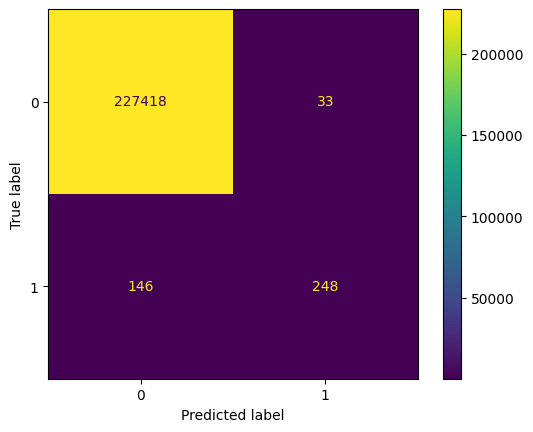

In [166]:
print("*" * 50)

confusionMatrix = confusion_matrix(yTrain,yTrain_Pred)
displayCM=ConfusionMatrixDisplay(confusionMatrix)

accuracyScore = accuracy_score(yTrain,yTrain_Pred)
precisionScore = precision_score(yTrain,yTrain_Pred)
recallscore = recall_score(yTrain,yTrain_Pred)
f1Score = f1_score(yTrain,yTrain_Pred)
aucRocCurve = roc_auc_score(yTrain,yTrain_Pred)

print(f"Accuracy Score: {accuracyScore:.2%}")
print(f"Precision Score: {precisionScore:.2%}") 
print(f"Recall Score: {recallscore:.2%}")
print(f"F1 Score: {f1Score:.2%}")
print(f"AUC ROC Curve: {aucRocCurve:.2%}")
print("*" * 50)

displayCM.plot()
py.show()

## Prediction and Evaluation of Model - Tresting Data

**************************************************
Accuracy Score: 99.91%
Precision Score: 82.67%
Recall Score: 63.27%
F1 Score: 71.68%
AUC ROC Curve: 81.62%
True Negative: 56851, False Positive: 13, False Negative: 36, True Positive: 62
Total fraud transaction caught: 62 out of 98 fraud transactions in the test data
Total legit transaction caught: 56851 out of 56864 legit transactions in the test data
**************************************************


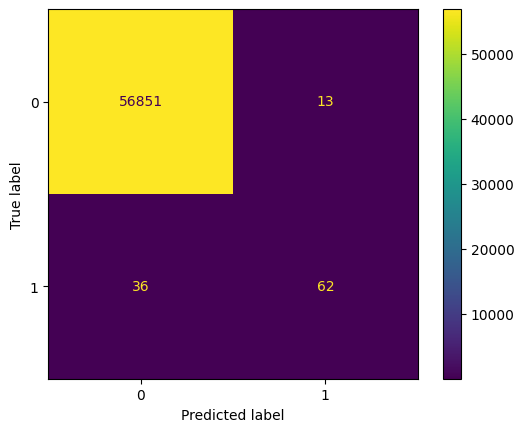

In [167]:
yTest_Pred=lg.predict(xTest_Scaled)

print("*" * 50)

confusionMatrix = confusion_matrix(yTest,yTest_Pred)
displayCM=ConfusionMatrixDisplay(confusionMatrix)

accuracyScore = accuracy_score(yTest,yTest_Pred)
precisionScore = precision_score(yTest,yTest_Pred)
recallscore = recall_score(yTest,yTest_Pred)
f1Score = f1_score(yTest,yTest_Pred)
aucRocCurve = roc_auc_score(yTest,yTest_Pred)

print(f"Accuracy Score: {accuracyScore:.2%}")
print(f"Precision Score: {precisionScore:.2%}") 
print(f"Recall Score: {recallscore:.2%}")
print(f"F1 Score: {f1Score:.2%}")
print(f"AUC ROC Curve: {aucRocCurve:.2%}")

tn, fp, fn, tp = confusionMatrix.ravel()
print(f"True Negative: {tn}, False Positive: {fp}, False Negative: {fn}, True Positive: {tp}")
print(f"Total fraud transaction caught: {tp} out of {tp+fn} fraud transactions in the test data")
print(f"Total legit transaction caught: {tn} out of {tn+fp} legit transactions in the test data")

print("*" * 50)

displayCM.plot()
py.show()


In [168]:
#Confusion matrix will give us the number of True Positive, True Negative, False Positive and False Negative. But it will not give us the precision, recall, f1 score and AUC ROC Curve. So, we will use classification report to get all these metrics in one go.
#Classification report will give us the precision, recall, f1 score and AUC ROC Curve for each class. It will also give us the support for each class. Support is the number of occurrences of each class in the dataset.   

print("Full classification report for training data: ")
print(classification_report(yTrain,yTrain_Pred, target_names=['Legit','Fraud']))

print("Full classification report for testing data: ")
print(classification_report(yTest,yTest_Pred, target_names=['Legit','Fraud']))

Full classification report for training data: 
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00    227451
       Fraud       0.88      0.63      0.73       394

    accuracy                           1.00    227845
   macro avg       0.94      0.81      0.87    227845
weighted avg       1.00      1.00      1.00    227845

Full classification report for testing data: 
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



In [169]:
#Dummy Classifier is a simple classifier that makes predictions based on simple rules. It is used as a baseline to compare the performance of other classifiers. It can be used to predict the most frequent class, the stratified random class, the uniform random class, or the constant class. In this case, we will use the most frequent class strategy, which means that it will always predict the class that is most frequent in the training data. This is a very simple model and it will not perform well on our dataset, but it will give us a baseline to compare our logistic regression model with.
from sklearn.dummy import DummyClassifier
dummyModel = DummyClassifier(strategy='most_frequent')

dummyModel.fit(xTrain_Scaled,yTrain)
dummyPred = dummyModel.predict(xTest_Scaled)

print(f"Dummy predictions: {dummyPred}")

Dummy predictions: [0 0 0 ... 0 0 0]


In [170]:
print("*" * 50)

confusionMatrix = confusion_matrix(yTest,dummyPred)
displayCM=ConfusionMatrixDisplay(confusionMatrix)

accuracyScore = accuracy_score(yTest,dummyPred)

print(f"Accuracy Score: {accuracyScore:.2%}")



print("*" * 50)


**************************************************
Accuracy Score: 99.83%
**************************************************


### Balancing the class - Improvement 1
- In this usecase, classifying a fraud as legit transaction is something that we cannot afford of. So, out of 98 only 68 were classified as fraud. Remaining is a classified as legit, which is a costly mistake. 
- Now, we can use resampling techniques(oversampling-rows getting duplicated, undersampling - rows getting removed,SMOTE - new dummy rows getting) or we can try to balance then data.
- We can do the above by adding **class_weight=balanced**.
- What does this mean???? The loss function or the internal algorithm penalises the mistakes of the minor data class in a large way than the major data class. Eg: The mistake of a fraud transaction is highlighted/considered way more than a legit one. The algo concentrates more on the fraud transaction during the training eriod.


Evaluation metrics of base Logistic Regression model - Vanilla
Accuracy Score: 99.83%
Precision Score: 82.67%
Recall Score: 63.27%
F1 Score: 71.68%
AUC ROC Curve: 81.62%
True Negative: 56851, False Positive: 13, False Negative: 36, True Positive: 62
Total fraud transaction caught: 62 out of 98 fraud transactions in the test data
Total legit transaction caught: 56851 out of 56864 legit transactions in the test data
**************************************************
Evaluation metrics of balanced Logistic Regression model - Improvement 1
Accuracy Score: 97.55%
Precision Score: 6.10%
Recall Score: 91.84%
F1 Score: 11.44%
AUC ROC Curve: 94.70%
True Negative: 55478, False Positive: 1386, False Negative: 8, True Positive: 90
Total fraud transaction caught: 90 out of 98 fraud transactions in the test data
Total legit transaction caught: 55478 out of 56864 legit transactions in the test data
**************************************************


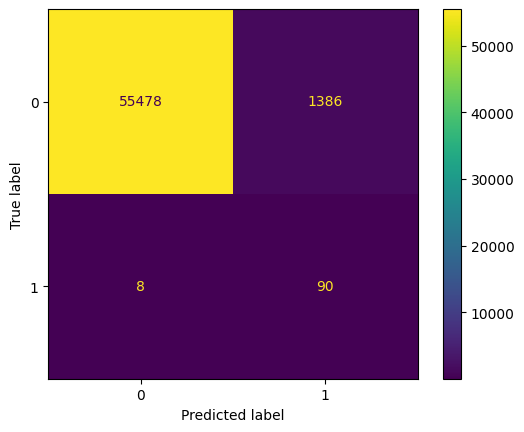

In [171]:
lgBalanced=LogisticRegression(max_iter=1000,class_weight='balanced')
lgBalanced.fit(xTrain_Scaled,yTrain)

yPred_Balanced=lgBalanced.predict(xTest_Scaled)


print("Evaluation metrics of base Logistic Regression model - Vanilla")

print(f"Accuracy Score: {accuracyScore:.2%}")
print(f"Precision Score: {precisionScore:.2%}") 
print(f"Recall Score: {recallscore:.2%}")
print(f"F1 Score: {f1Score:.2%}")
print(f"AUC ROC Curve: {aucRocCurve:.2%}")
print(f"True Negative: {tn}, False Positive: {fp}, False Negative: {fn}, True Positive: {tp}")
print(f"Total fraud transaction caught: {tp} out of {tp+fn} fraud transactions in the test data")
print(f"Total legit transaction caught: {tn} out of {tn+fp} legit transactions in the test data")

confusionMatrix = confusion_matrix(yTest,yPred_Balanced)
displayCM=ConfusionMatrixDisplay(confusionMatrix)

print("*" * 50)


print("Evaluation metrics of balanced Logistic Regression model - Improvement 1")

accuracyScore = accuracy_score(yTest,yPred_Balanced)
precisionScore = precision_score(yTest,yPred_Balanced)
recallscore = recall_score(yTest,yPred_Balanced)
f1Score = f1_score(yTest,yPred_Balanced)
aucRocCurve = roc_auc_score(yTest,yPred_Balanced)

print(f"Accuracy Score: {accuracyScore:.2%}")
print(f"Precision Score: {precisionScore:.2%}") 
print(f"Recall Score: {recallscore:.2%}")
print(f"F1 Score: {f1Score:.2%}")
print(f"AUC ROC Curve: {aucRocCurve:.2%}")

tn, fp, fn, tp = confusionMatrix.ravel()
print(f"True Negative: {tn}, False Positive: {fp}, False Negative: {fn}, True Positive: {tp}")
print(f"Total fraud transaction caught: {tp} out of {tp+fn} fraud transactions in the test data")
print(f"Total legit transaction caught: {tn} out of {tn+fp} legit transactions in the test data")

print("*" * 50)

displayCM.plot()
py.show()




- From the above metrics, the precision has fall from 82% to 6%(out of the actual positives, how many positives I have found of class 0). This is creating lot of false alarms. Even thsi is also a bad model. The recall has improved, but at the cost of precision.
- We have to again improve our model, by using resampling techniques.

### Random UnderSampling.
- Choosing random data from the class which is majority and merging it with minor class data, to create 50:50 balance.
- Resampling (whether undersampling or oversampling) should only be applied to the training data, never to the test data.
The test set should represent real-world data. If you also undersample the test set: you're no longer evaluating your model on the actual class distribution it will face in production. Metrics like accuracy, precision, recall, and ROC-AUC may no longer reflect real-world performance.

In [172]:
rus = RandomUnderSampler()
xTrain_rus,yTrain_rus = rus.fit_resample(xTrain_Scaled,yTrain)

print(f"Before under sampling: Legit: {int((yTrain == 0).sum()): ,}, Fraud: {int((yTrain.sum()))}")
print(f"After under sampling: Legit: {int((yTrain_rus == 0).sum()): ,}, Fraud: {int((yTrain_rus.sum()))}")
print(f"{len(yTrain) - len(yTrain_rus):,} entries of Legit transactions are eliminated to bring in 50:50 ratio")

Before under sampling: Legit:  227,451, Fraud: 394
After under sampling: Legit:  394, Fraud: 394
227,057 entries of Legit transactions are eliminated to bring in 50:50 ratio


****************************************************************************************************
Evaluation metrics of Balanced Logistic Regression model - Improvement 1
****************************************************************************************************
Accuracy Score: 97.55%
Precision Score: 6.10%
Recall Score: 91.84%
F1 Score: 11.44%
AUC ROC Curve: 94.70%
True Negative: 55478, False Positive: 1386, False Negative: 8, True Positive: 90
Total fraud transaction caught: 90 out of 98 fraud transactions in the test data
Total legit transaction caught: 55478 out of 56864 legit transactions in the test data
****************************************************************************************************
Evaluation metrics of Under Sampled Logistic Regression model - Improvement 2
****************************************************************************************************
Accuracy Score: 96.95%
Precision Score: 4.94%
Recall Score: 91.84%
F1 Score: 9.38%
AUC ROC

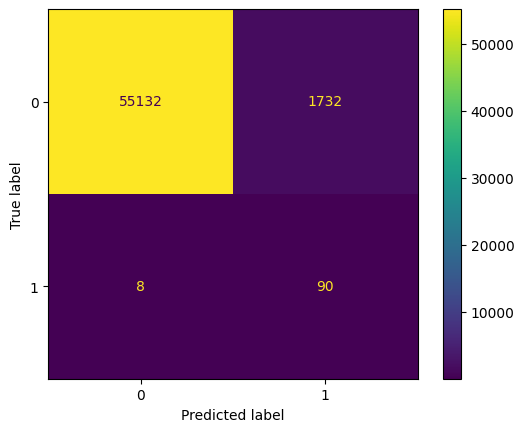

In [173]:
lgUS=LogisticRegression(max_iter=1000)
lgUS.fit(xTrain_rus,yTrain_rus)

yPred_US=lgUS.predict(xTest_Scaled)

print("*" * 100)
print("Evaluation metrics of Balanced Logistic Regression model - Improvement 1")
print("*" * 100)

print(f"Accuracy Score: {accuracyScore:.2%}")
print(f"Precision Score: {precisionScore:.2%}") 
print(f"Recall Score: {recallscore:.2%}")
print(f"F1 Score: {f1Score:.2%}")
print(f"AUC ROC Curve: {aucRocCurve:.2%}")
print(f"True Negative: {tn}, False Positive: {fp}, False Negative: {fn}, True Positive: {tp}")
print(f"Total fraud transaction caught: {tp} out of {tp+fn} fraud transactions in the test data")
print(f"Total legit transaction caught: {tn} out of {tn+fp} legit transactions in the test data")

confusionMatrix = confusion_matrix(yTest,yPred_US)
displayCM=ConfusionMatrixDisplay(confusionMatrix)

print("*" * 100)
print("Evaluation metrics of Under Sampled Logistic Regression model - Improvement 2")
print("*" * 100)

accuracyScore = accuracy_score(yTest,yPred_US)
precisionScore = precision_score(yTest,yPred_US)
recallscore = recall_score(yTest,yPred_US)
f1Score = f1_score(yTest,yPred_US)
aucRocCurve = roc_auc_score(yTest,yPred_US)

print(f"Accuracy Score: {accuracyScore:.2%}")
print(f"Precision Score: {precisionScore:.2%}") 
print(f"Recall Score: {recallscore:.2%}")
print(f"F1 Score: {f1Score:.2%}")
print(f"AUC ROC Curve: {aucRocCurve:.2%}")

tn, fp, fn, tp = confusionMatrix.ravel()
print(f"True Negative: {tn}, False Positive: {fp}, False Negative: {fn}, True Positive: {tp}")
print(f"Total fraud transaction caught: {tp} out of {tp+fn} fraud transactions in the test data")
print(f"Total legit transaction caught: {tn} out of {tn+fp} legit transactions in the test data")

print("*" * 100)

displayCM.plot()
py.show()




- Even in the Improvemnt 2, we didn't see great improvemnt. The precision,f1 score is still low.

### SMOTE - Synthetic Minority Over-sampling Technique
- The approach of removing the majority class data is not working.
- So, we are going to synthesize(creates) new minority class entries.
- These synthetic fraud samples will be picked-up using KNN(K-nearest neighbours). For Eg: If 5 fraud points are picked up by the KNN algo near to an actual fraud point, then for 10 actual fraud points, we will get 50(5 for every point) synthetic points. These are the invisible (or) non-existing points, in terms of our original dataset. 

## How KNN Works in SMOTE

One common misconception is that **KNN in SMOTE finds invisible or missing data points**. This is **not true**.

### Step 1: Find the k Nearest Minority Neighbors

SMOTE considers **only the minority class samples** (e.g., fraud transactions).

For each minority sample:
1. Compute its distance to every other minority sample (usually using Euclidean distance).
2. Select the **k nearest minority neighbors**.

For example:

```
Fraud Sample A ●

Nearest Fraud Samples:
● B
● C
● D
● E
● F
```

The nearest neighbors are **existing data points**, not imaginary ones.

---

### Step 2: Create a Synthetic Sample

SMOTE randomly selects one of the nearest neighbors (say B,actual fraud sample) and creates a **new sample between A and B**.

```
Original Samples

● A ---------------------- ● B

Synthetic Sample

● A -------- ★ ----------- ● B
```

The new point (★) is generated using:

\[
\text{New Sample} = A + r(B - A)
\]

where:

- **A** = original minority sample
- **B** = one of its nearest minority neighbors
- **r** = random number between 0 and 1

Thus, the new sample lies **somewhere on the line joining A and B**.

---

### Why Does This Make Sense?

The assumption is:

> If two minority samples are very similar, then another sample lying between them is also likely to belong to the minority class.

Instead of duplicating existing fraud samples (Random Oversampling), SMOTE creates **new, realistic-looking synthetic samples**, helping the model learn a better decision boundary.

---

### Important Notes

- KNN **does not** search for invisible or missing data points.
- KNN only identifies the **nearest existing minority samples**.
- The synthetic sample is **created mathematically** between two existing minority samples.
- In datasets with many features, these points exist in a **multi-dimensional feature space**, even though we cannot visualize them.

### Example::
- A = (20, 50), B = (40, 90)
- r = 0.4
- B - A => (40-20,90-50) = (20,40)
- (20,40) * 0.4 = (8,16)
- Add with A => (20,50)+(8,16)=(28,66)
- The new fraud point is (28,66)

In [174]:
sm = SMOTE()
xTrain_sm,yTrain_sm = sm.fit_resample(xTrain_Scaled,yTrain)

print(f"Before SMOTE: Legit: {int((yTrain == 0).sum()): ,}, Fraud: {int((yTrain.sum()))}")
print(f"After SMOTE: Legit: {int((yTrain_sm == 0).sum()): ,}, Fraud: {int((yTrain_sm.sum()))}")
print(f"{len(yTrain_sm) - len(yTrain):,} entries of Fraud transactions are synthesized to bring in 50:50 ratio")

Before SMOTE: Legit:  227,451, Fraud: 394
After SMOTE: Legit:  227,451, Fraud: 227451
227,057 entries of Fraud transactions are synthesized to bring in 50:50 ratio


****************************************************************************************************
Evaluation metrics of Under Sampled Logistic Regression model - Improvement 2
****************************************************************************************************
Accuracy Score: 96.95%
Precision Score: 4.94%
Recall Score: 91.84%
F1 Score: 9.38%
AUC ROC Curve: 94.40%
True Negative: 55132, False Positive: 1732, False Negative: 8, True Positive: 90
Total fraud transaction caught: 90 out of 98 fraud transactions in the test data
Total legit transaction caught: 55132 out of 56864 legit transactions in the test data
****************************************************************************************************
Evaluation metrics of Smote Logistic Regression model - Improvement 3
****************************************************************************************************
Accuracy Score: 97.41%
Precision Score: 5.77%
Recall Score: 91.84%
F1 Score: 10.86%
AUC ROC Cu

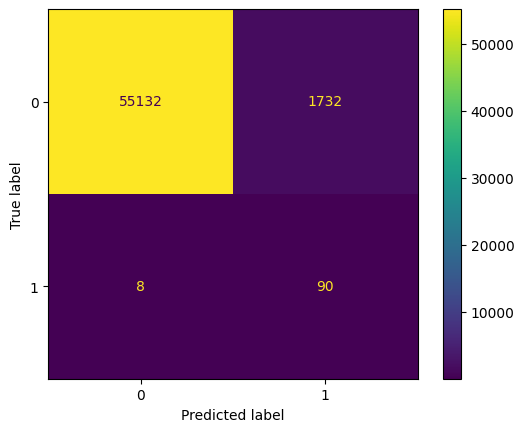

In [ ]:
lgSmote=LogisticRegression(max_iter=1000)
lgSmote.fit(xTrain_sm,yTrain_sm)

yPred_Smote=lgSmote.predict(xTest_Scaled)

print("*" * 100)
print("Evaluation metrics of Under Sampled Logistic Regression model - Improvement 2")
print("*" * 100)

print(f"Accuracy Score: {accuracyScore:.2%}")
print(f"Precision Score: {precisionScore:.2%}") 
print(f"Recall Score: {recallscore:.2%}")
print(f"F1 Score: {f1Score:.2%}")
print(f"AUC ROC Curve: {aucRocCurve:.2%}")
print(f"True Negative: {tn}, False Positive: {fp}, False Negative: {fn}, True Positive: {tp}")
print(f"Total fraud transaction caught: {tp} out of {tp+fn} fraud transactions in the test data")
print(f"Total legit transaction caught: {tn} out of {tn+fp} legit transactions in the test data")

confusionMatrix = confusion_matrix(yTest,yPred_Smote)
displayCM=ConfusionMatrixDisplay(confusionMatrix)

print("*" * 100)
print("Evaluation metrics of Smote Logistic Regression model - Improvement 3")
print("*" * 100)

accuracyScore = accuracy_score(yTest,yPred_Smote)
precisionScore = precision_score(yTest,yPred_Smote)
recallscore = recall_score(yTest,yPred_Smote)
f1Score = f1_score(yTest,yPred_Smote)
aucRocCurve = roc_auc_score(yTest,yPred_Smote)

print(f"Accuracy Score: {accuracyScore:.2%}")
print(f"Precision Score: {precisionScore:.2%}") 
print(f"Recall Score: {recallscore:.2%}")
print(f"F1 Score: {f1Score:.2%}")
print(f"AUC ROC Curve: {aucRocCurve:.2%}")

tn, fp, fn, tp = confusionMatrix.ravel()
print(f"True Negative: {tn}, False Positive: {fp}, False Negative: {fn}, True Positive: {tp}")
print(f"Total fraud transaction caught: {tp} out of {tp+fn} fraud transactions in the test data")
print(f"Total legit transaction caught: {tn} out of {tn+fp} legit transactions in the test data")

print("*" * 100)

displayCM.plot()
py.show()




#### Why even SMOTE didn't workout????
- This is because, we trying to stretch 98 records tpo 227451 records. Which is like 99.99% duplications.
- The duplicate points might be good or bad. We don't know about it.
- So, instead of duplicationg at such a high ration, we can control it to some fixed point, through ***Sampling Ratio***

### SMOTE - with Sampling Ratio

In [177]:
#Sampling Ratio/Sampling Strategy=10%
sm_partial = SMOTE(sampling_strategy=0.1)
xTrain_smp,yTrain_smp = sm_partial.fit_resample(xTrain_Scaled,yTrain)

print(f"Before SMOTE: Legit: {int((yTrain == 0).sum()): ,}, Fraud: {int((yTrain.sum()))}")
print(f"After SMOTE: Legit: {int((yTrain_smp == 0).sum()): ,}, Fraud: {int((yTrain_smp.sum()))}")
print(f"{len(yTrain_smp) - len(yTrain):,} entries of Fraud transactions are synthesized")

Before SMOTE: Legit:  227,451, Fraud: 394
After SMOTE: Legit:  227,451, Fraud: 22745
22,351 entries of Fraud transactions are synthesized


****************************************************************************************************
Evaluation metrics of Smote Logistic Regression model - Improvement 3
****************************************************************************************************
Accuracy Score: 97.41%
Precision Score: 5.77%
Recall Score: 91.84%
F1 Score: 10.86%
AUC ROC Curve: 94.63%
True Negative: 55132, False Positive: 1732, False Negative: 8, True Positive: 90
Total fraud transaction caught: 90 out of 98 fraud transactions in the test data
Total legit transaction caught: 55132 out of 56864 legit transactions in the test data
****************************************************************************************************
Evaluation metrics of Smote Partial(10% resampling) Logistic Regression model - Improvement 4
****************************************************************************************************
Accuracy Score: 99.71%
Precision Score: 35.95%
Recall Score: 88.78%
F1 Score:

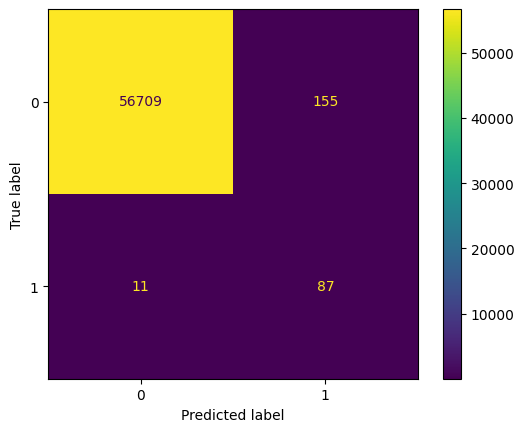

In [178]:
lgSmoteP=LogisticRegression(max_iter=1000)
lgSmoteP.fit(xTrain_smp,yTrain_smp)

yPred_SmoteP=lgSmoteP.predict(xTest_Scaled)

print("*" * 100)
print("Evaluation metrics of Smote Logistic Regression model - Improvement 3")
print("*" * 100)

print(f"Accuracy Score: {accuracyScore:.2%}")
print(f"Precision Score: {precisionScore:.2%}") 
print(f"Recall Score: {recallscore:.2%}")
print(f"F1 Score: {f1Score:.2%}")
print(f"AUC ROC Curve: {aucRocCurve:.2%}")
print(f"True Negative: {tn}, False Positive: {fp}, False Negative: {fn}, True Positive: {tp}")
print(f"Total fraud transaction caught: {tp} out of {tp+fn} fraud transactions in the test data")
print(f"Total legit transaction caught: {tn} out of {tn+fp} legit transactions in the test data")

confusionMatrix = confusion_matrix(yTest,yPred_SmoteP)
displayCM=ConfusionMatrixDisplay(confusionMatrix)

print("*" * 100)
print("Evaluation metrics of Smote Partial(10% resampling) Logistic Regression model - Improvement 4")
print("*" * 100)

accuracyScore = accuracy_score(yTest,yPred_SmoteP)
precisionScore = precision_score(yTest,yPred_SmoteP)
recallscore = recall_score(yTest,yPred_SmoteP)
f1Score = f1_score(yTest,yPred_SmoteP)
aucRocCurve = roc_auc_score(yTest,yPred_SmoteP)

print(f"Accuracy Score: {accuracyScore:.2%}")
print(f"Precision Score: {precisionScore:.2%}") 
print(f"Recall Score: {recallscore:.2%}")
print(f"F1 Score: {f1Score:.2%}")
print(f"AUC ROC Curve: {aucRocCurve:.2%}")

tn, fp, fn, tp = confusionMatrix.ravel()
print(f"True Negative: {tn}, False Positive: {fp}, False Negative: {fn}, True Positive: {tp}")
print(f"Total fraud transaction caught: {tp} out of {tp+fn} fraud transactions in the test data")
print(f"Total legit transaction caught: {tn} out of {tn+fp} legit transactions in the test data")

print("*" * 100)

displayCM.plot()
py.show()


